In [68]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize, LogNorm


# 1. plot noise spectra

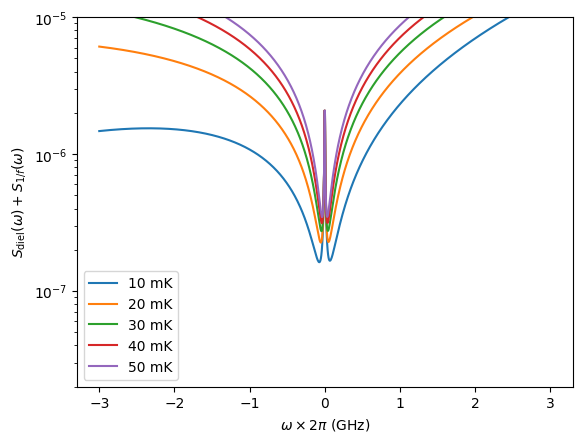

In [169]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 42 ,tangent_ref = 1e-5 ):

    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ


    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?


temp_list = [10,20,30,40,50]
omega_array = np.linspace(-3,3,1000)

eta = 5e-5
EC = 3/8
EL = 3/30
for temp in temp_list:
    gamma_diel = diel_spectral_density(omega_array, EC,temp ,tangent_ref = 1e-5 )
    gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)
    plt.plot(omega_array, gamma_diel+gamma_one_over_f,label = f"{temp} mK")

plt.ylim(2e-8,1e-5)
plt.yscale('log')
plt.xlabel(rf"$\omega \times 2\pi$ (GHz)")
plt.ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")
plt.legend()

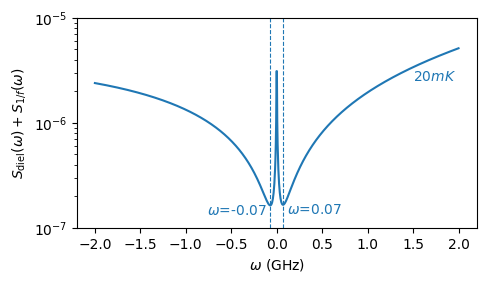

In [170]:
from scipy.signal import argrelextrema

omega_array = np.linspace(-2,2,1000)
fig, ax = plt.subplots(figsize=(5, 3))
fig.subplots_adjust(left=0.15, bottom=0.2, right=0.95, top=0.9)

eta = 5e-5
EC = 3/4
EL = 3/30


for temp,color  in zip([20],['#1f77b4','#ff7f0e']):
    gamma_diel = diel_spectral_density(omega_array, EC,temp ,tangent_ref = 1e-5 )
    gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)

    spectra = gamma_diel+gamma_one_over_f

    ax.plot(omega_array, spectra,label = f"{temp} mK",color=color)


    local_minima_indices = argrelextrema(spectra, np.less)[0]
    first_local_minima_idx = local_minima_indices[0]
    second_local_minima_idx = local_minima_indices[1]
    ax.axvline(x = omega_array[first_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
    ax.axvline(x = omega_array[second_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
    ax.text(x=omega_array[first_local_minima_idx]-0.04,y=spectra[first_local_minima_idx]-3e-8,s=rf"$\omega$={omega_array[first_local_minima_idx]:.2f}",ha='right', color=color)
    ax.text(x=omega_array[second_local_minima_idx]+0.04,y=spectra[second_local_minima_idx]-3e-8,s=rf"$\omega$={omega_array[second_local_minima_idx]:.2f}",ha='left', color=color)

# ax.text(1.0,6e-6,r'$40 mK$',color='#ff7f0e')
ax.text(1.5,2.5e-6,r'$20 mK$',color='#1f77b4')


ax.set_ylim(1e-7,1e-5)
ax.set_yscale('log')
# ax.set_xlabel(rf"$\omega \times 2\pi$ (GHz)")
ax.set_xlabel(rf"$\omega$ (GHz)")
ax.set_ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")
# plt.legend()

plt.savefig('spectra.pdf')


# Step-2 plot decoherence times

In [171]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,51)
EJ_over_EC_list = np.linspace(2,12,101)
X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v4_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


frequencys = {
    "conventional":conventional_freq_array,
    "upside_down12":upside_down_freq12_array
}
phi_ele = {
    "conventional":conventional_phi_element_array,
    "upside_down12":upside_down_phi_element12_array
}

In [172]:
hbar = 1/(2*np.pi)

def compute_lifetimes(one_over_f_flux_noise_amplitude,
                      temp_in_mK, 
                      tangent_ref):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j]

            conventional_dielectric_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * diel_spectral_density(omega_conventional, EC,temp_in_mK,tangent_ref  ))
            conventional_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * one_over_f_spectral_density(omega_conventional, EL,one_over_f_flux_noise_amplitude )) 
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]

            upside_down12_dielectric_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * diel_spectral_density(omega_upside_down12, EC,temp_in_mK,tangent_ref))
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * one_over_f_spectral_density(omega_upside_down12, EL,one_over_f_flux_noise_amplitude )) 
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

In [173]:
diff_in_T_tot = []
list_of_ref_tangent = np.linspace(np.log10(1e-6),
                                  np.log10(1e-5),
                                  100)
list_of_ref_tangent = 10**list_of_ref_tangent

one_over_f_flux_noise_amplitude = 1.4e-6
temp = 20

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for tangent in list_of_ref_tangent:
    lifetimes = compute_lifetimes(one_over_f_flux_noise_amplitude, 
                                  temp,
                                  tangent)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)
        T1_dielectric_results[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
        T1_1overf_results[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)

for catagory in ["conventional", "upside_down01", "upside_down12"]:
    tot_results[catagory] = np.array(tot_results[catagory])
    Tphi_results[catagory] = np.array(Tphi_results[catagory])
    T1_results[catagory] = np.array(T1_results[catagory])
    T1_dielectric_results[catagory] = np.array(T1_dielectric_results[catagory])
    T1_1overf_results[catagory] = np.array(T1_1overf_results[catagory])

/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_70122/731244531.py:42: RuntimeWarning: divide by zero encountered in divide
  T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_70122/731244531.py:43: RuntimeWarning: divide by zero encountered in divide
  tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))


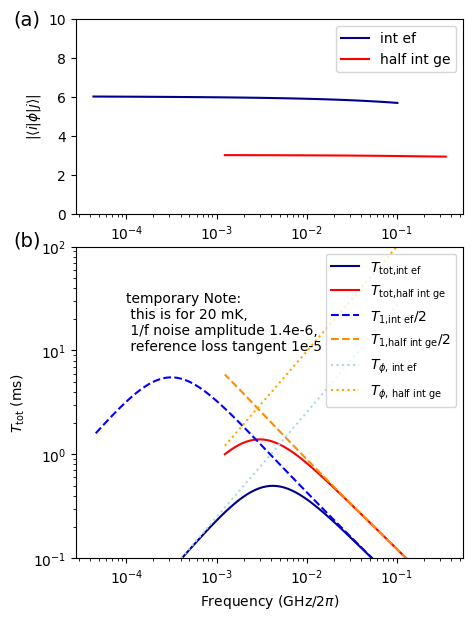

In [174]:
fig, axes = plt.subplots(2,1,figsize = (5,7),height_ratios=[1,1.6])
plt.subplots_adjust(hspace=0.13)
EL_idx = 20
noise_profile_idx = -1
axes[0].plot()
axes[0].plot(frequencys["upside_down12"][EL_idx, :],phi_ele["upside_down12"][EL_idx, :], label = rf'int ef',color = 'darkblue')
axes[0].plot(frequencys["conventional"][EL_idx, :],phi_ele["conventional"][EL_idx, :], label = rf'half int ge',color = 'red')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_ylim(0,10)
# axes[0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[0].set_ylabel(r'$| \langle i | \phi | j \rangle|$')


axes[1].plot(frequencys["upside_down12"][EL_idx, :],tot_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_\text{{tot,int ef}}$',color = 'darkblue')
axes[1].plot(frequencys["conventional"][EL_idx, :],tot_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_\text{{tot,half int ge}}$',color = 'red')

axes[1].plot(frequencys["upside_down12"][EL_idx, :],T1_results["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_\text{{1,int ef}}$/2',color = 'blue', linestyle='dashed')
axes[1].plot(frequencys["conventional"][EL_idx, :],T1_results["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_\text{{1,half int ge}}/2$',color = 'darkorange', linestyle='dashed')

axes[1].plot(frequencys["upside_down12"][EL_idx, :],Tphi_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, int ef}}}}$',color = 'lightblue', linestyle='dotted')
axes[1].plot(frequencys["conventional"][EL_idx, :],Tphi_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, half int ge}}}}$',color = 'orange', linestyle='dotted')


axes[1].text(1e-4,1e1,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6, \n reference loss tangent 1e-5")

axes[1].legend(loc='upper right')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-1,1e2)
axes[1].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[1].set_ylabel(rf'$T_\text{{tot}}$ (ms)')

axes[0].text(-0.16, 1.05, '(a)', transform=axes[0].transAxes, fontsize=14, verticalalignment='top')
axes[1].text(-0.16, 1.05, '(b)', transform=axes[1].transAxes, fontsize=14, verticalalignment='top')

plt.savefig('phi_element vs freq.pdf')


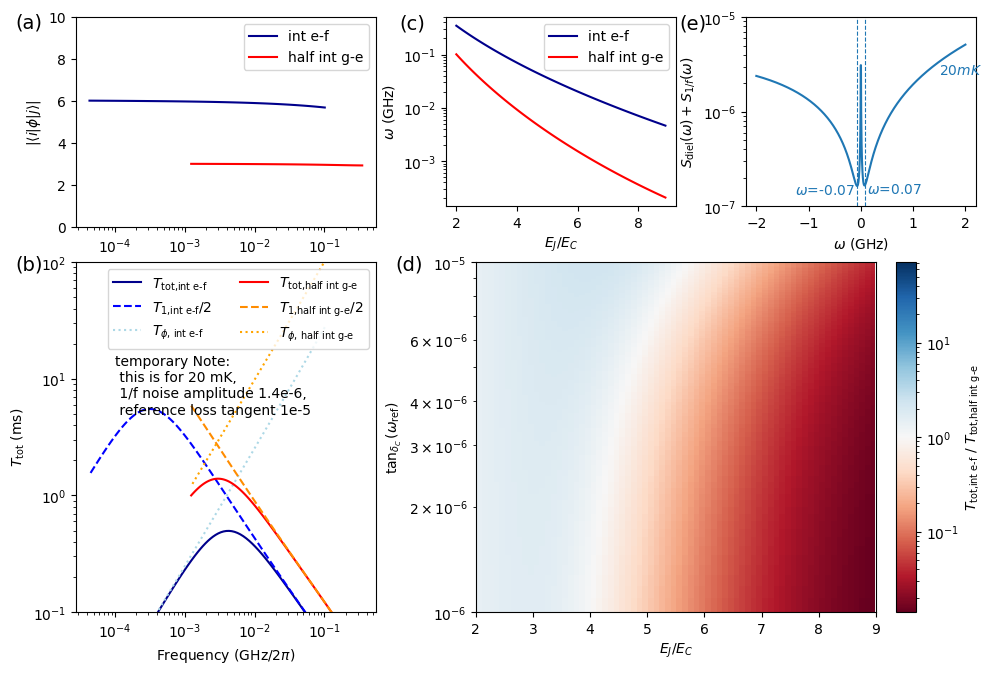

In [229]:
from matplotlib.gridspec import GridSpec

UIFQ_label='int e-f'
conventional_label='half int g-e'

fig = plt.figure(figsize = (10,7))

wspaces = [0.08,0.1]
bottom_vspace = 0.1
middle_vspace = 0.05
column_widths_first_row = [0.3,0.23,0.23]
column_widths_second_row = [0.3,0.4,0.02]
row_heights = [0.3,0.5]
axes = [
    [fig.add_axes([wspaces[0],                                                                                           bottom_vspace + row_heights[1]+middle_vspace,             column_widths_first_row[0],        row_heights[0]]),
      fig.add_axes([wspaces[0]+0.07  + column_widths_first_row[0],                                                     bottom_vspace + row_heights[1]+middle_vspace + 0.03,             column_widths_first_row[1],        row_heights[0]-0.03]),
      fig.add_axes([wspaces[0]+0.07 +0.07  + column_widths_first_row[0] + column_widths_first_row[1],                      bottom_vspace + row_heights[1]+middle_vspace+ 0.03,             column_widths_first_row[2],          row_heights[0]-0.03])],
    [
        fig.add_axes([wspaces[0],                                                                                    bottom_vspace,                                                  column_widths_second_row[0],               row_heights[1]]),
        fig.add_axes([wspaces[0]+wspaces[1] + column_widths_second_row[0],                                             bottom_vspace,                                                column_widths_second_row[1],               row_heights[1]]),
        fig.add_axes([wspaces[0]+wspaces[1]  + column_widths_second_row[0] + column_widths_second_row[1]+0.02,         bottom_vspace,                                                column_widths_second_row[2],                                      row_heights[1]]) 
    ]
]
# plt.subplots_adjust(hspace=0.13)
# plt.subplots_adjust(wspace=0.3)

EL_idx = 20
noise_profile_idx = -1
# axes[0,0].plot()
axes[0][0].plot(frequencys["upside_down12"][EL_idx, :],phi_ele["upside_down12"][EL_idx, :], label = UIFQ_label,color = 'darkblue')
axes[0][0].plot(frequencys["conventional"][EL_idx, :],phi_ele["conventional"][EL_idx, :], label = conventional_label,color = 'red')
axes[0][0].legend()
axes[0][0].set_xscale('log')
axes[0][0].set_ylim(0,10)
# axes[0][0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[0][0].set_ylabel(r'$| \langle i | \phi | j \rangle|$')


axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],tot_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],T1_results["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],Tphi_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')

axes[1][0].plot(frequencys["conventional"][EL_idx, :],tot_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
axes[1][0].plot(frequencys["conventional"][EL_idx, :],T1_results["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
axes[1][0].plot(frequencys["conventional"][EL_idx, :],Tphi_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')


axes[1][0].text(1e-4,5e0,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6, \n reference loss tangent 1e-5")

axes[1][0].legend(loc='upper right', ncol=2)
axes[1][0].set_xscale('log')
axes[1][0].set_yscale('log')
axes[1][0].set_ylim(1e-1,1e2)
axes[1][0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[1][0].set_ylabel(rf'$T_\text{{tot}}$ (ms)')


EC_idx = -31

axes[0][1].plot(EJ_over_EC_list[:EC_idx] ,frequencys["conventional"][EL_idx, :EC_idx], label = UIFQ_label,color = 'darkblue')
axes[0][1].plot(EJ_over_EC_list[:EC_idx] ,frequencys["upside_down12"][EL_idx, :EC_idx], label = conventional_label,color = 'red')
axes[0][1].set_yscale('log')
axes[0][1].set_ylabel(r'$\omega$ (GHz)')
axes[0][1].set_xlabel(r'$E_J/E_C$')
axes[0][1].legend()
ratio = tot_results['upside_down12'][:,EL_idx,:EC_idx] / tot_results['conventional'][:,EL_idx,:EC_idx]

log_min = np.log10(np.min(ratio))
log_max = np.log10(np.max(ratio))

max_distance = max(abs(log_min), abs(log_max))

vmin = 10**(-max_distance)
vmax = 10**max_distance

norm = LogNorm(vmin=vmin, vmax=vmax)

cax = axes[1][1].imshow(ratio, cmap = 'RdBu', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EC_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
axes[1][1].set_yscale('log')
cbar = fig.colorbar(cax, cax=axes[1][2])
cbar.set_label(rf'$T_{{\text{{tot,{UIFQ_label}}}}}$ / $T_{{\text{{tot,{conventional_label}}}}}$')
axes[1][1].set_xlabel(r'$E_J/E_C$')
axes[1][1].set_ylabel(r'$\tan_{\delta_C} (\omega_\text{ref})$')






from scipy.signal import argrelextrema

omega_array = np.linspace(-2,2,1000)

eta = 5e-5
EC = 3/4
EL = 3/30
for temp,color  in zip([20],['#1f77b4','#ff7f0e']):
    gamma_diel = diel_spectral_density(omega_array, EC,temp ,tangent_ref = 1e-5 )
    gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)

    spectra = gamma_diel+gamma_one_over_f

    axes[0][2].plot(omega_array, spectra,label = f"{temp} mK",color=color)


    local_minima_indices = argrelextrema(spectra, np.less)[0]
    first_local_minima_idx = local_minima_indices[0]
    second_local_minima_idx = local_minima_indices[1]
    axes[0][2].axvline(x = omega_array[first_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
    axes[0][2].axvline(x = omega_array[second_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
    axes[0][2].text(x=omega_array[first_local_minima_idx]-0.04,y=spectra[first_local_minima_idx]-3e-8,s=rf"$\omega$={omega_array[first_local_minima_idx]:.2f}",ha='right', color=color)
    axes[0][2].text(x=omega_array[second_local_minima_idx]+0.04,y=spectra[second_local_minima_idx]-3e-8,s=rf"$\omega$={omega_array[second_local_minima_idx]:.2f}",ha='left', color=color)

# axes[0][2].text(1.0,6e-6,r'$40 mK$',color='#ff7f0e')
axes[0][2].text(1.5,2.5e-6,r'$20 mK$',color='#1f77b4')


axes[0][2].set_ylim(1e-7,1e-5)
axes[0][2].set_yscale('log')
# axes[0][2].set_xlabel(rf"$\omega \times 2\pi$ (GHz)")
axes[0][2].set_xlabel(rf"$\omega$ (GHz)")
axes[0][2].set_ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")






axes[0][0].text(-0.2, 1.02, '(a)', transform=axes[0][0].transAxes, fontsize=14, verticalalignment='top')
axes[0][1].text(-0.2, 1.02, '(c)', transform=axes[0][1].transAxes, fontsize=14, verticalalignment='top')
axes[0][1].text(-0.29, 1.02, '(e)', transform=axes[0][2].transAxes, fontsize=14, verticalalignment='top')

axes[1][0].text(-0.2, 1.02, '(b)', transform=axes[1][0].transAxes, fontsize=14, verticalalignment='top')
axes[1][1].text(-0.2, 1.02, '(d)', transform=axes[1][1].transAxes, fontsize=14, verticalalignment='top')

plt.savefig('phi_element vs freq.pdf')


In [ ]:
from matplotlib.gridspec import GridSpec

UIFQ_label='int e-f'
conventional_label='half int g-e'

fig = plt.figure(figsize = (10,7))

wspaces = [0.08,0.1]
bottom_vspace = 0.1
middle_vspace = 0.05
column_widths = [0.3,0.4,0.1]
row_heights = [0.3,0.5]
axes = [
    [fig.add_axes([wspaces[0],                                              bottom_vspace + row_heights[1]+middle_vspace,             column_widths[0], row_heights[0]]),
      fig.add_axes([wspaces[0]+wspaces[1]  + column_widths[0],                      bottom_vspace + row_heights[1]+middle_vspace,             column_widths[1], row_heights[0]])],
    [
        fig.add_axes([wspaces[0],                                             0.1,                                                  column_widths[0], row_heights[1]]),
        fig.add_axes([wspaces[0]+wspaces[1] + column_widths[0],                       0.1,                                                column_widths[1], row_heights[1]]),
        fig.add_axes([wspaces[0]+wspaces[1]  + column_widths[0] + column_widths[1]+0.02,   0.1,                                                0.02,row_heights[1]]) 
    ]
]
plt.subplots_adjust(hspace=0.13)
plt.subplots_adjust(wspace=0.3)

EL_idx = 20
noise_profile_idx = -1
# axes[0,0].plot()
axes[0][0].plot(frequencys["upside_down12"][EL_idx, :],phi_ele["upside_down12"][EL_idx, :], label = UIFQ_label,color = 'darkblue')
axes[0][0].plot(frequencys["conventional"][EL_idx, :],phi_ele["conventional"][EL_idx, :], label = conventional_label,color = 'red')
axes[0][0].legend()
axes[0][0].set_xscale('log')
axes[0][0].set_ylim(0,10)
# axes[0][0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[0][0].set_ylabel(r'$| \langle i | \phi | j \rangle|$')


axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],tot_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],T1_results["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
axes[1][0].plot(frequencys["upside_down12"][EL_idx, :],Tphi_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')

axes[1][0].plot(frequencys["conventional"][EL_idx, :],tot_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
axes[1][0].plot(frequencys["conventional"][EL_idx, :],T1_results["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
axes[1][0].plot(frequencys["conventional"][EL_idx, :],Tphi_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')


axes[1][0].text(1e-4,1e1,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6, \n reference loss tangent 1e-5")

axes[1][0].legend(loc='upper right', ncol=2)
axes[1][0].set_xscale('log')
axes[1][0].set_yscale('log')
axes[1][0].set_ylim(1e-1,1e2)
axes[1][0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[1][0].set_ylabel(rf'$T_\text{{tot}}$ (ms)')


EC_idx = -31

axes[0][1].plot(EJ_over_EC_list[:EC_idx] ,frequencys["conventional"][EL_idx, :EC_idx], label = UIFQ_label,color = 'darkblue')
axes[0][1].plot(EJ_over_EC_list[:EC_idx] ,frequencys["upside_down12"][EL_idx, :EC_idx], label = conventional_label,color = 'red')
axes[0][1].set_yscale('log')
axes[0][1].set_ylabel(r'$\omega$ (GHz)')
axes[0][1].legend()
ratio = tot_results['upside_down12'][:,EL_idx,:EC_idx] / tot_results['conventional'][:,EL_idx,:EC_idx]

log_min = np.log10(np.min(ratio))
log_max = np.log10(np.max(ratio))

max_distance = max(abs(log_min), abs(log_max))

vmin = 10**(-max_distance)
vmax = 10**max_distance

norm = LogNorm(vmin=vmin, vmax=vmax)

cax = axes[1][1].imshow(ratio, cmap = 'RdBu', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EC_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
axes[1][1].set_yscale('log')
cbar = fig.colorbar(cax, cax=axes[1][2])
cbar.set_label(rf'$T_{{\text{{tot,{UIFQ_label}}}}}$ / $T_{{\text{{tot,{conventional_label}}}}}$')
axes[1][1].set_xlabel(r'$E_J/E_C$')
axes[1][1].set_ylabel(r'$\tan_{\delta_C} (\omega_\text{ref})$')


axes[0][0].text(-0.2, 1.05, '(a)', transform=axes[0][0].transAxes, fontsize=14, verticalalignment='top')
axes[1][0].text(-0.2, 1.05, '(b)', transform=axes[1][0].transAxes, fontsize=14, verticalalignment='top')
axes[0][1].text(-0.2, 1.05, '(c)', transform=axes[0][1].transAxes, fontsize=14, verticalalignment='top')
axes[1][1].text(-0.2, 1.05, '(d)', transform=axes[1][1].transAxes, fontsize=14, verticalalignment='top')

plt.savefig('phi_element vs freq.pdf')


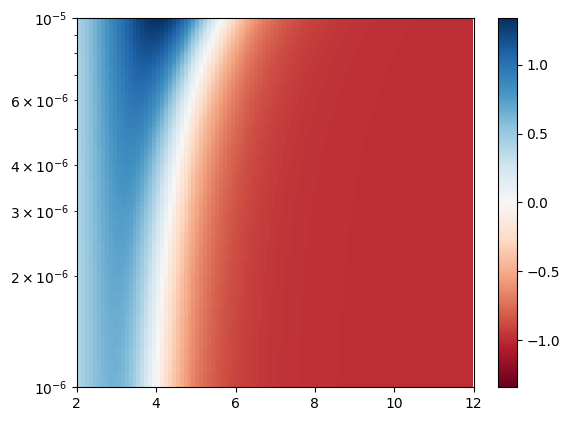

In [67]:
EL_idx = 20

diff = tot_results['upside_down12'][:,EL_idx,:] - tot_results['conventional'][:,EL_idx,:]

diff_relative = diff / tot_results['conventional'][:,EL_idx,:]
norm = Normalize(vmin=-np.max(np.abs(diff_relative)), vmax=np.max(np.abs(diff_relative)))

plt.imshow(diff_relative[:,:], cmap = 'RdBu', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[-1],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
plt.yscale('log')
plt.colorbar()

In [82]:
EJ_over_EC_list[-31]

9.0

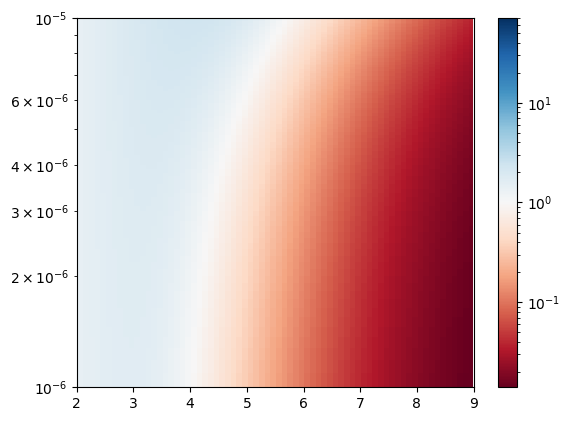

In [85]:
EL_idx = 20
EC_idx = -31
ratio = tot_results['upside_down12'][:,EL_idx,:EC_idx] / tot_results['conventional'][:,EL_idx,:EC_for_10]

log_min = np.log10(np.min(ratio))
log_max = np.log10(np.max(ratio))

max_distance = max(abs(log_min), abs(log_max))

vmin = 10**(-max_distance)
vmax = 10**max_distance

norm = LogNorm(vmin=vmin, vmax=vmax)

plt.imshow(ratio, cmap = 'RdBu', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EC_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
plt.yscale('log')
plt.colorbar()

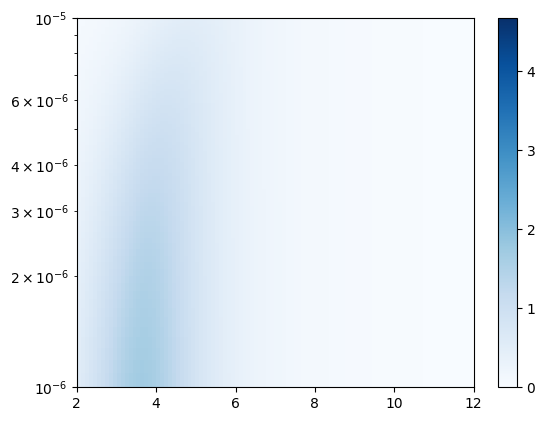

In [64]:
norm = Normalize(vmin = 0,vmax=max(np.max(tot_results['upside_down12'][:,EL_idx,:]),  
                             np.max(tot_results['conventional'][:,EL_idx,:]) )
                             )

plt.imshow(tot_results['upside_down12'][:,EL_idx,:], cmap = 'Blues', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[-1],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
plt.yscale('log')
plt.colorbar()

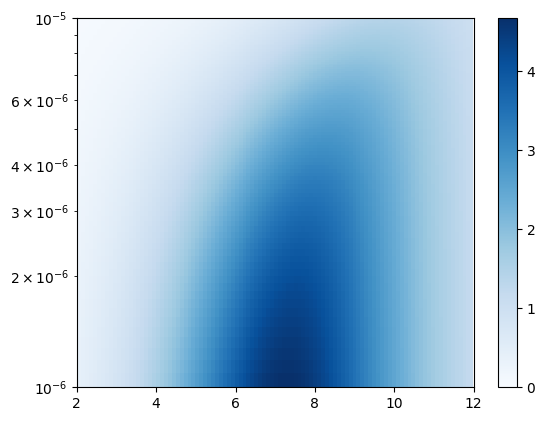

In [65]:
norm = Normalize(vmin = 0,vmax=max(np.max(tot_results['upside_down12'][:,EL_idx,:]),  
                             np.max(tot_results['conventional'][:,EL_idx,:]) )
                             )

plt.imshow(tot_results['conventional'][:,EL_idx,:], cmap = 'Blues', norm=norm,
           extent=[ EJ_over_EC_list[0], EJ_over_EC_list[-1],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
           )
plt.yscale('log')
plt.colorbar()

In [51]:
diff_relative

array([[ 0.41209499,  0.45046038,  0.48759375, ..., -0.99099385,
        -0.99103081, -0.9910622 ],
       [ 0.41272343,  0.45130715,  0.4887224 , ..., -0.99098909,
        -0.99102641, -0.99105814],
       [ 0.41333799,  0.45213546,  0.48982685, ..., -0.99098421,
        -0.99102191, -0.99105398],
       ...,
       [ 0.43701126,  0.48422091,  0.53291183, ..., -0.98926423,
        -0.989434  , -0.98958686],
       [ 0.43707954,  0.48431396,  0.53303765, ..., -0.98921877,
        -0.98939203, -0.98954808],
       [ 0.43714627,  0.48440489,  0.53316061, ..., -0.98917225,
        -0.98934908, -0.98950839]])

In [33]:
diff.shape

(100, 101)

In [38]:
diff[:5,:].shape

(5, 101)